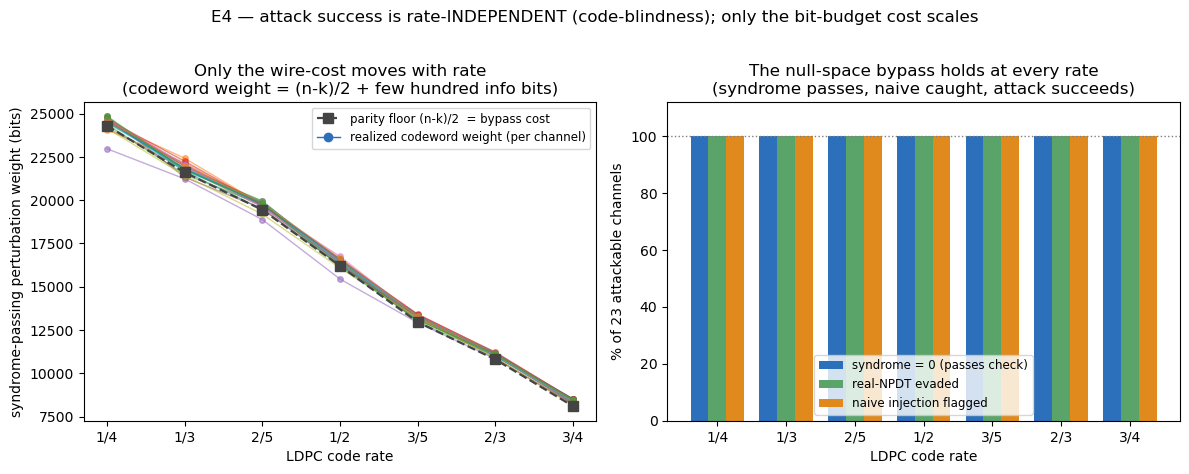

In [2]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

E4 = json.load(open(Path("runs_e4/e4_summary.json")))
rates = [p["rate"] for p in E4[0]["per_rate"]]
x = np.arange(len(rates))
floor = np.array([p["parity_floor"] for p in E4[0]["per_rate"]])
wt = np.array([[p["delta_total_weight_med"] for p in d["per_rate"]] for d in E4])  # chan x rate
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
axL.plot(x, floor, "s--", color="#444", lw=1.6, ms=7, label="parity floor (n-k)/2  = bypass cost", zorder=3)
for row, d in zip(wt, E4):
    axL.plot(x, row, "o-", lw=1, ms=4, alpha=0.55)
axL.plot([], [], "o-", color="#2c6fbb", lw=1, label="realized codeword weight (per channel)")
axL.set_xticks(x); axL.set_xticklabels(rates)
axL.set_xlabel("LDPC code rate"); axL.set_ylabel("syndrome-passing perturbation weight (bits)")
axL.set_title("Only the wire-cost moves with rate\n(codeword weight = (n-k)/2 + few hundred info bits)")
axL.legend(fontsize=8.5, loc="upper right")
n = len(E4)
synd = [100*np.mean([p["frac_frames_syndrome0"]==1.0 for p in d["per_rate"]]) for d in E4]
def frac(metric):
    return [100*np.mean([d["per_rate"][i][metric] == (0.0 if metric=="" else d["per_rate"][i][metric]) for d in E4]) for i in range(len(rates))]
syndrome0 = [100*np.mean([d["per_rate"][i]["frac_frames_syndrome0"]==1.0 for d in E4]) for i in range(len(rates))]
naiveflag = [100*np.mean([d["per_rate"][i]["frac_frames_naive_flagged"]==1.0 for d in E4]) for i in range(len(rates))]
verdict   = [100*np.mean([d["per_rate"][i]["real_npdt_missed"] for d in E4]) for i in range(len(rates))]
w = 0.26
axR.bar(x-w, syndrome0, w, color="#2c6fbb", label="syndrome = 0 (passes check)")
axR.bar(x,   verdict,   w, color="#5aa469", label="real-NPDT evaded")
axR.bar(x+w, naiveflag, w, color="#e08a1e", label="naive injection flagged")
axR.set_xticks(x); axR.set_xticklabels(rates); axR.set_ylim(0, 112)
axR.set_xlabel("LDPC code rate"); axR.set_ylabel(f"% of {n} attackable channels")
axR.axhline(100, color="gray", ls=":", lw=1)
axR.set_title("The null-space bypass holds at every rate\n(syndrome passes, naive caught, attack succeeds)")
axR.legend(fontsize=8.5, loc="lower center")
fig.suptitle("E4 — attack success is rate-INDEPENDENT (code-blindness); only the bit-budget cost scales", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()